In [3]:
%matplotlib inline
# Célula 1 — Imports e carregamento das bases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.style.use('dark_background')
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.2f}'.format)

# Carregamento das bases
DATA_DIR = Path("data")
df_bol = pd.read_csv(DATA_DIR / "base_boletos_fiap.csv", 
                     parse_dates=["dt_emissao","dt_vencimento","dt_pagamento"])
df_aux = pd.read_csv(DATA_DIR / "base_auxiliar_fiap.csv")

print(f"Base boletos: {df_bol.shape[0]} registros, {df_bol.shape[1]} colunas")
print(f"Base auxiliar: {df_aux.shape[0]} registros, {df_aux.shape[1]} colunas")
df_bol.head()

Base boletos: 7118 registros, 10 colunas
Base auxiliar: 4612 registros, 11 colunas


,id_boleto,id_pagador,id_beneficiario,dt_emissao,dt_vencimento,dt_pagamento,vlr_nominal,vlr_baixa,tipo_baixa,tipo_especie
0,00c6dec1b869d310010c8e3741262d7e96b0a622a7cf40...,24037765228ca1bce6743570728395541ca481ac79d854...,cf98a6d61719ae21047ea999c57051ffcae0809677068f...,2024-03-27,2024-05-09,2024-03-29,2714.66,NaN,5 - Baixa integral por solicitacao do cedente,DM DUPLICATA MERCANTIL
1,6548008e566d8f6696c5561a845248f61bfd2e3891711c...,24037765228ca1bce6743570728395541ca481ac79d854...,a711fb1183bc159fdcb672d61f9e052cda50f9e0a76e68...,2024-03-13,2024-05-05,2024-05-06,5522.63,5522.63,1 - Baixa integral intrabancaria,DMI DUPLICATA MERCANTIL INDICACAO
2,7409b9a978ccf059c68841c2317a3196adfd8d405854fa...,1c63664185066fb412e0803d751efbde86444efd8c265f...,8b4a7a67986a724fbc3ea10174aef547975c3d7257a3b1...,2024-05-17,2024-05-30,2024-05-27,3338.30,3338.30,0 - Baixa integral interbancaria,DM DUPLICATA MERCANTIL
3,2ef9ddc070a19a5af5d06c5605dc4fa90dc67052e70ffa...,1c63664185066fb412e0803d751efbde86444efd8c265f...,8b4a7a67986a724fbc3ea10174aef547975c3d7257a3b1...,2024-05-16,2024-05-29,2024-05-20,4519.18,4519.18,0 - Baixa integral interbancaria,DM DUPLICATA MERCANTIL
4,59e12a5e65532caf3bdb053f0e6d7af3b10a34b6c69029...,db8c5dc48c47d5ecae33324ee886afa21de700c19d8154...,00ac28a417bb5fe5daeafecd84190e8d794ed125971502...,2024-03-28,2024-05-27,2024-05-27,13416.18,13416.18,0 - Baixa integral interbancaria,DMI DUPLICATA MERCANTIL INDICACAO


In [5]:
# Célula 2 — Cálculo do DPD (Dias de Atraso)
df_bol["dpd"] = (df_bol["dt_pagamento"] - df_bol["dt_vencimento"]).dt.days.fillna(999)
df_bol["em_atraso"]  = df_bol["dpd"] > 0
df_bol["atraso_30"]  = df_bol["dpd"] >= 30
df_bol["atraso_60"]  = df_bol["dpd"] >= 60
df_bol["atraso_90"]  = df_bol["dpd"] >= 90

print("=== Resumo de Atrasos ===")
print(f"Total de boletos:         {len(df_bol)}")
print(f"Boletos em atraso:        {df_bol['em_atraso'].sum()} ({df_bol['em_atraso'].mean()*100:.1f}%)")
print(f"Atraso >= 30 dias (PD30): {df_bol['atraso_30'].sum()} ({df_bol['atraso_30'].mean()*100:.1f}%)")
print(f"Atraso >= 60 dias (PD60): {df_bol['atraso_60'].sum()} ({df_bol['atraso_60'].mean()*100:.1f}%)")
print(f"Atraso >= 90 dias (PD90): {df_bol['atraso_90'].sum()} ({df_bol['atraso_90'].mean()*100:.1f}%)")

=== Resumo de Atrasos ===
Total de boletos:         7118
Boletos em atraso:        2157 (30.3%)
Atraso >= 30 dias (PD30): 464 (6.5%)
Atraso >= 60 dias (PD60): 432 (6.1%)
Atraso >= 90 dias (PD90): 103 (1.4%)


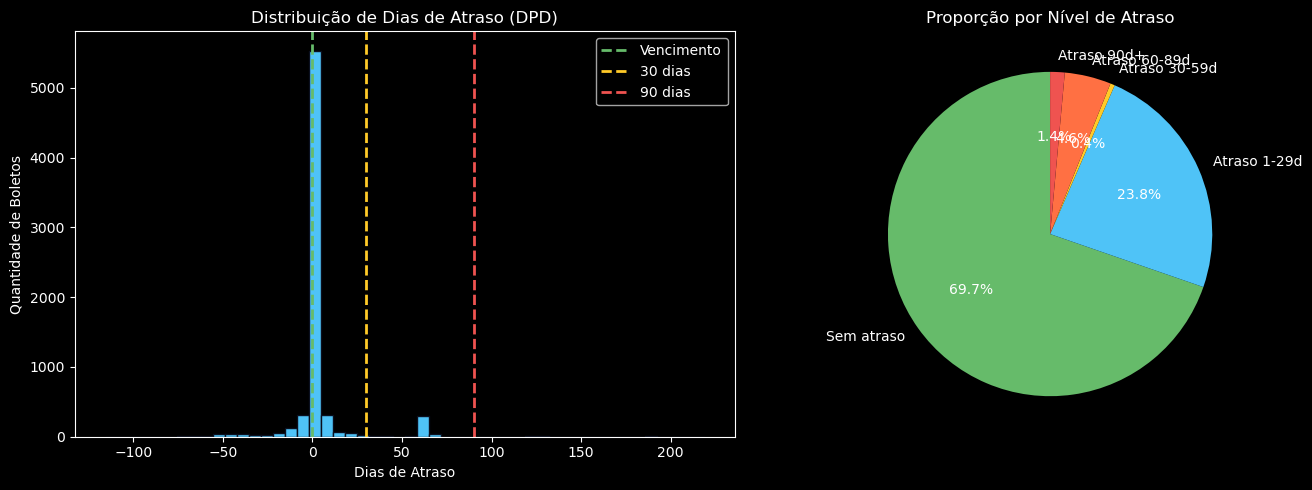

In [7]:
# Célula 3 — Gráfico de distribuição do DPD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição dos DPDs
dpd_validos = df_bol[df_bol["dpd"] < 999]["dpd"]
axes[0].hist(dpd_validos, bins=50, color='#4fc3f7', edgecolor='#0a0f1e')
axes[0].axvline(0,  color='#66bb6a', linestyle='--', linewidth=2, label='Vencimento')
axes[0].axvline(30, color='#ffca28', linestyle='--', linewidth=2, label='30 dias')
axes[0].axvline(90, color='#ef5350', linestyle='--', linewidth=2, label='90 dias')
axes[0].set_title('Distribuição de Dias de Atraso (DPD)', color='white')
axes[0].set_xlabel('Dias de Atraso', color='white')
axes[0].set_ylabel('Quantidade de Boletos', color='white')
axes[0].legend()

# Gráfico 2: Pizza de níveis de atraso
labels = ['Sem atraso', 'Atraso 1-29d', 'Atraso 30-59d', 'Atraso 60-89d', 'Atraso 90d+']
sizes = [
    (~df_bol['em_atraso']).sum(),
    (df_bol['em_atraso'] & ~df_bol['atraso_30']).sum(),
    (df_bol['atraso_30'] & ~df_bol['atraso_60']).sum(),
    (df_bol['atraso_60'] & ~df_bol['atraso_90']).sum(),
    df_bol['atraso_90'].sum(),
]
colors = ['#66bb6a','#4fc3f7','#ffca28','#ff7043','#ef5350']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção por Nível de Atraso', color='white')

plt.tight_layout()
plt.show()

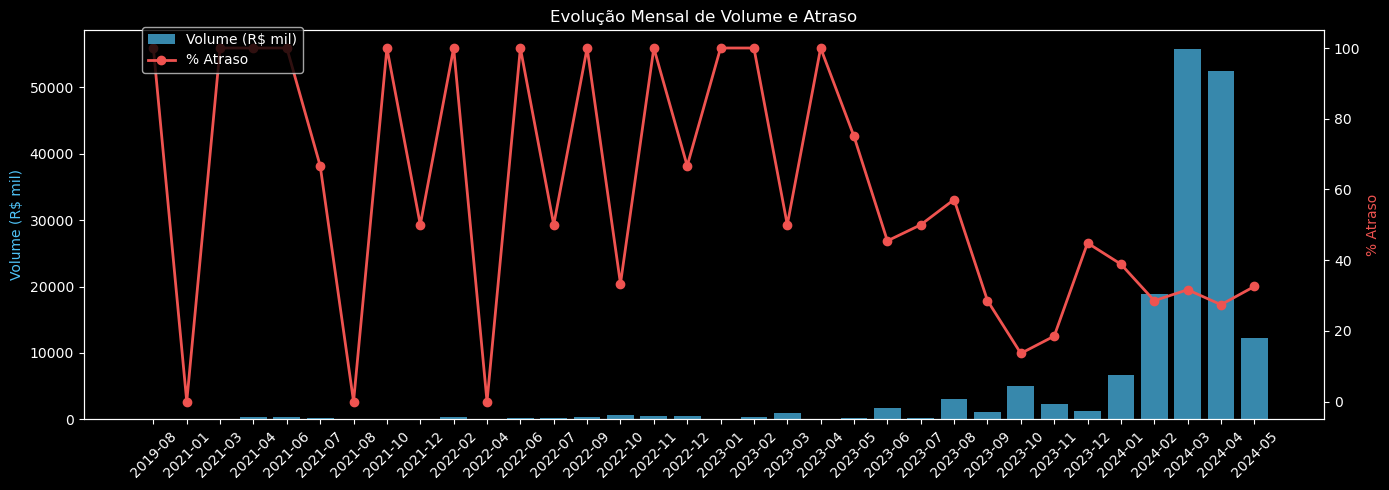

In [9]:
# Célula 4 — Sazonalidade mensal
df_bol["mes_emissao"] = df_bol["dt_emissao"].dt.to_period("M").astype(str)

ts = df_bol.groupby("mes_emissao").agg(
    n_boletos  =("id_boleto",  "count"),
    pct_atraso =("em_atraso",  "mean"),
    vlr_total  =("vlr_nominal","sum"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(ts["mes_emissao"], ts["vlr_total"]/1000, color='#4fc3f7', alpha=0.7, label="Volume (R$ mil)")
ax1.set_ylabel("Volume (R$ mil)", color='#4fc3f7')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(ts["mes_emissao"], ts["pct_atraso"]*100, color='#ef5350', marker='o', linewidth=2, label="% Atraso")
ax2.set_ylabel("% Atraso", color='#ef5350')

ax1.set_title("Evolução Mensal de Volume e Atraso", color='white')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

In [11]:
# Célula 5 — Feature Engineering e cruzamento das bases
agg = df_bol.groupby("id_beneficiario").agg(
    total_boletos    =("id_boleto",   "count"),
    vlr_total        =("vlr_nominal", "sum"),
    vlr_medio        =("vlr_nominal", "mean"),
    pct_atraso_geral =("em_atraso",   "mean"),
    pct_atraso_30    =("atraso_30",   "mean"),
    pct_atraso_60    =("atraso_60",   "mean"),
    pct_atraso_90    =("atraso_90",   "mean"),
    dpd_medio        =("dpd", lambda x: x[x<999].mean() if (x<999).any() else 0),
    n_pagadores      =("id_pagador",  "nunique"),
).reset_index()

# Cruzamento com base auxiliar
df = agg.merge(df_aux, left_on="id_beneficiario", right_on="id_cnpj", how="left")

print(f"Beneficiários únicos: {len(df)}")
print(f"\nFeatures criadas:")
print(df.columns.tolist())
df.head()

Beneficiários únicos: 1189

Features criadas:
['id_beneficiario', 'total_boletos', 'vlr_total', 'vlr_medio', 'pct_atraso_geral', 'pct_atraso_30', 'pct_atraso_60', 'pct_atraso_90', 'dpd_medio', 'n_pagadores', 'id_cnpj', 'cd_cnae_prin', 'uf', 'sacado_indice_liquidez_1m', 'cedente_indice_liquidez_1m', 'score_materialidade_evolucao', 'media_atraso_dias', 'indicador_liquidez_quantitativo_3m', 'share_vl_inad_pag_bol_6_a_15d', 'score_quantidade_v2', 'score_materialidade_v2']


,id_beneficiario,total_boletos,vlr_total,vlr_medio,pct_atraso_geral,pct_atraso_30,pct_atraso_60,pct_atraso_90,dpd_medio,n_pagadores,...,cd_cnae_prin,uf,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m,score_materialidade_evolucao,media_atraso_dias,indicador_liquidez_quantitativo_3m,share_vl_inad_pag_bol_6_a_15d,score_quantidade_v2,score_materialidade_v2
0,0005d5a4788b6928107f7dd9589bdb461ba489f0be57fb...,2,17350.10,8675.05,0.50,0.00,0.00,0.00,0.50,2,...,4672900.00,RJ,0.99,0.81,965.00,249.13,0.96,0.00,982.00,988.00
1,000b70c46b4a8ed5b66fc7179d4a2e256d5f244422e694...,1,11110.93,11110.93,0.00,0.00,0.00,0.00,0.00,1,...,2532201.00,SP,0.86,0.93,834.00,113.67,0.87,0.46,976.00,989.00
2,001f0eb33fd25d6b45fa6552c005abfe4f891d73a10c85...,1,1311.16,1311.16,1.00,1.00,1.00,0.00,62.00,1,...,4744001.00,SP,0.05,NaN,111.00,56.01,0.26,0.04,134.00,781.00
3,0038b1b99d6e5bcff666fa46160edc6598e9869f072540...,1,2389.44,2389.44,1.00,0.00,0.00,0.00,2.00,1,...,2219600.00,SP,0.89,NaN,774.00,173.00,0.67,0.00,940.00,987.00
4,00588ae0dcec3cb5145246f7da03fa74f5685eea2efe47...,7,36169.00,5167.00,0.43,0.14,0.14,0.14,24.00,7,...,4723700.00,SP,0.76,0.32,694.00,171.86,0.92,0.43,264.00,964.00


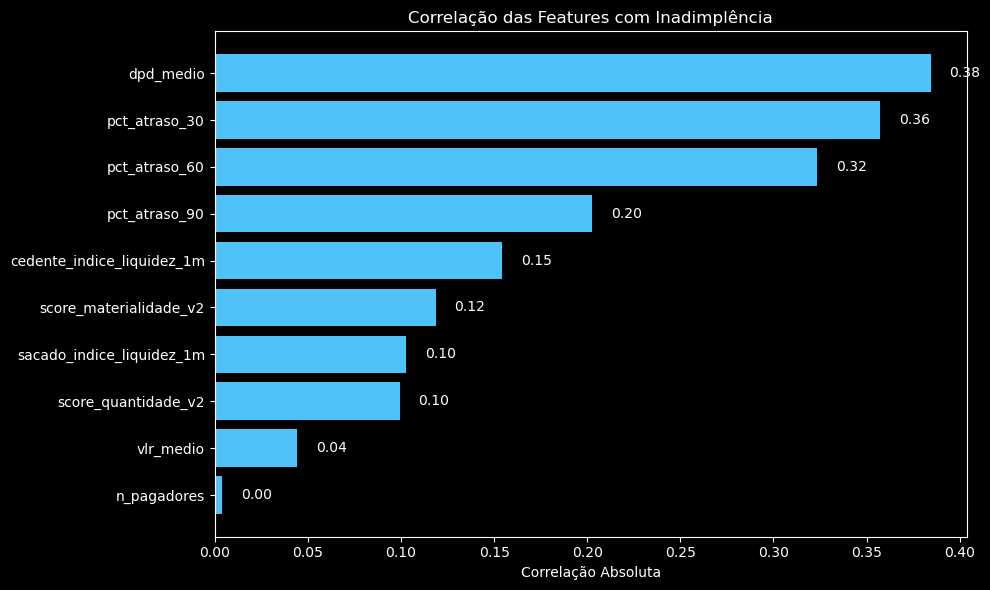


✅ EDA completa! Notebook pronto para evidência na apresentação.


In [13]:
# Célula 6 — Análise das features principais
features = ['pct_atraso_30', 'pct_atraso_60', 'pct_atraso_90', 
            'dpd_medio', 'vlr_medio', 'n_pagadores',
            'score_materialidade_v2', 'score_quantidade_v2',
            'sacado_indice_liquidez_1m', 'cedente_indice_liquidez_1m']

correlacoes = df[features].corrwith(df['pct_atraso_geral']).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(correlacoes.index, correlacoes.values, color='#4fc3f7')
ax.set_title('Correlação das Features com Inadimplência', color='white')
ax.set_xlabel('Correlação Absoluta', color='white')
for bar, val in zip(bars, correlacoes.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

print("\n✅ EDA completa! Notebook pronto para evidência na apresentação.")

In [15]:
# Verificação — bate com o MVP?
from data_loader import load_data

df_mvp, df_bol_mvp = load_data()

print("=== NOTEBOOK ===")
print(f"Beneficiários: {len(df)}")
print(f"Pct atraso 30 médio: {df['pct_atraso_30'].mean()*100:.1f}%")
print(f"Vlr total: R$ {df['vlr_total'].sum()/1e6:.1f}M")

print("\n=== MVP (data_loader) ===")
print(f"Beneficiários: {len(df_mvp)}")
print(f"Pct atraso 30 médio: {df_mvp['pct_atraso_30'].mean()*100:.1f}%")
print(f"Vlr total: R$ {df_mvp['vlr_total'].sum()/1e6:.1f}M")

=== NOTEBOOK ===
Beneficiários: 1189
Pct atraso 30 médio: 4.7%
Vlr total: R$ 165.9M

=== MVP (data_loader) ===
Beneficiários: 1189
Pct atraso 30 médio: 4.7%
Vlr total: R$ 165.9M
